<a href="https://colab.research.google.com/github/Janpu-Hou/IoT_Cybersecurity/blob/main/IoTMal_LightGBM_vs_SLM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
import lightgbm as lgb

In [2]:
# Load the dataset
df = pd.read_csv('/content/balanced_df_5000.csv')

# Display the first 5 rows of the DataFrame
display(df.head())

,Header_Length,Protocol Type,Time_To_Live,Rate,fin_flag_number,syn_flag_number,rst_flag_number,psh_flag_number,ack_flag_number,ece_flag_number,...,Tot sum,Min,Max,AVG,Std,Tot size,IAT,Number,Variance,MalwareFamily
0,10.160554,17,51.933963,9.613700,0.0,0.305734,0.0,0.0,0.0,0.0,...,1468,42,342,146.879895,138.258776,146.879895,0.104854,10,19122.601458,Agent
1,20.000000,6,64.000000,19.864773,0.0,1.000000,0.0,0.0,0.0,0.0,...,540,54,54,54.000000,0.000000,54.000000,0.051002,10,0.000000,Agent
2,0.000000,1,64.000000,998643.809524,0.0,0.000000,0.0,0.0,0.0,0.0,...,820,82,82,82.000000,0.000000,82.000000,0.000002,10,0.000000,Agent
3,8.000000,17,64.000000,3.049037,0.0,0.000000,0.0,0.0,0.0,0.0,...,3420,342,342,342.000000,0.000000,342.000000,0.350354,10,0.000000,Agent
4,20.000000,6,64.000000,443.598880,0.0,1.000000,0.0,0.0,0.0,0.0,...,540,54,54,54.000000,0.000000,54.000000,0.003882,10,0.000000,Agent


In [3]:
# Get a concise summary of the DataFrame including data types and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 40 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Header_Length    45000 non-null  float64
 1   Protocol Type    45000 non-null  int64  
 2   Time_To_Live     45000 non-null  float64
 3   Rate             45000 non-null  float64
 4   fin_flag_number  45000 non-null  float64
 5   syn_flag_number  45000 non-null  float64
 6   rst_flag_number  45000 non-null  float64
 7   psh_flag_number  45000 non-null  float64
 8   ack_flag_number  45000 non-null  float64
 9   ece_flag_number  45000 non-null  float64
 10  cwr_flag_number  45000 non-null  float64
 11  ack_count        45000 non-null  int64  
 12  syn_count        45000 non-null  int64  
 13  fin_count        45000 non-null  int64  
 14  rst_count        45000 non-null  int64  
 15  HTTP             45000 non-null  float64
 16  HTTPS            45000 non-null  float64
 17  DNS         

In [5]:
# Display the number of unique values in the 'MalwareFamily' column
print(f"Number of unique labels: {df['MalwareFamily'].nunique()}")

# Display the value counts for the 'MalwareFamily' column
print("\nValue counts for 'MalwareFamily':")
display(df['MalwareFamily'].value_counts())

Number of unique labels: 9

Value counts for 'MalwareFamily':


,count
MalwareFamily,
Agent,5000
Benign,5000
DarkNexus,5000
Gafgyt,5000
Generic,5000
Mirai,5000
Rudedevil,5000
Tsunami,5000
Unknown,5000


In [6]:
# Encode the target variable 'MalwareFamily'
le = LabelEncoder()
df['MalwareFamily_encoded'] = le.fit_transform(df['MalwareFamily'])

# Define features (X) and target (y)
X = df.drop(['MalwareFamily', 'MalwareFamily_encoded'], axis=1)
y = df['MalwareFamily_encoded']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (31500, 39)
X_test shape: (13500, 39)
y_train shape: (31500,)
y_test shape: (13500,)


In [7]:
# Initialize and train the LightGBM Classifier
lgb_clf = lgb.LGBMClassifier(objective='multiclass', num_class=len(le.classes_), random_state=42)
lgb_clf.fit(X_train, y_train)

print("LightGBM Classifier trained successfully!")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011291 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5594
[LightGBM] [Info] Number of data points in the train set: 31500, number of used features: 33
[LightGBM] [Info] Start training from score -2.197225
[LightGBM] [Info] Start training from score -2.197225
[LightGBM] [Info] Start training from score -2.197225
[LightGBM] [Info] Start training from score -2.197225
[LightGBM] [Info] Start training from score -2.197225
[LightGBM] [Info] Start training from score -2.197225
[LightGBM] [Info] Start training from score -2.197225
[LightGBM] [Info] Start training from score -2.197225
[LightGBM] [Info] Start training from score -2.197225
LightGBM Classifier trained successfully!


In [8]:
# Make predictions on the test set
y_pred = lgb_clf.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=le.classes_)

print(f"Accuracy: {accuracy:.4f}")
print("Classification Report:\n", report)

Accuracy: 0.6519
Classification Report:
               precision    recall  f1-score   support

       Agent       0.67      0.83      0.74      1500
      Benign       0.87      0.98      0.93      1500
   DarkNexus       0.53      0.51      0.52      1500
      Gafgyt       0.76      0.53      0.63      1500
     Generic       0.54      0.63      0.58      1500
       Mirai       0.34      0.28      0.31      1500
   Rudedevil       0.68      0.89      0.77      1500
     Tsunami       0.85      0.95      0.90      1500
     Unknown       0.46      0.26      0.33      1500

    accuracy                           0.65     13500
   macro avg       0.63      0.65      0.63     13500
weighted avg       0.63      0.65      0.63     13500



In [14]:
import time
import joblib
import os

# --- LightGBM Performance Measurement ---

# Re-initialize and train LightGBM for accurate timing
print("Measuring LightGBM performance...")
start_time = time.time()
lgb_clf_timed = lgb.LGBMClassifier(objective='multiclass', num_class=len(le.classes_), random_state=42)
lgb_clf_timed.fit(X_train, y_train)
lgbm_train_time = time.time() - start_time

# Measure inference latency
start_time = time.time()
lgb_clf_timed.predict(X_test)
lgbm_inference_time = time.time() - start_time

# Save model and get size
lgbm_model_filename = 'lightgbm_model.pkl'
joblib.dump(lgb_clf_timed, lgbm_model_filename)
lgbm_model_size_mb = os.path.getsize(lgbm_model_filename) / (1024 * 1024)

print(f"LightGBM Training Time: {lgbm_train_time:.4f} seconds")
print(f"LightGBM Inference Time (on {len(X_test)} samples): {lgbm_inference_time:.4f} seconds")
print(f"LightGBM Model Size: {lgbm_model_size_mb:.2f} MB")

lgbm_accuracy = accuracy_score(y_test, lgb_clf_timed.predict(X_test))
print(f"LightGBM Accuracy: {lgbm_accuracy:.4f}")

Measuring LightGBM performance...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002886 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2550
[LightGBM] [Info] Number of data points in the train set: 28800, number of used features: 10
[LightGBM] [Info] Start training from score -2.197225
[LightGBM] [Info] Start training from score -2.197225
[LightGBM] [Info] Start training from score -2.197225
[LightGBM] [Info] Start training from score -2.197225
[LightGBM] [Info] Start training from score -2.197225
[LightGBM] [Info] Start training from score -2.197225
[LightGBM] [Info] Start training from score -2.197225
[LightGBM] [Info] Start training from score -2.197225
[LightGBM] [Info] Start training from score -2.197225


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM Training Time: 4.0937 seconds
LightGBM Inference Time (on 7200 samples): 0.6579 seconds
LightGBM Model Size: 2.91 MB


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM Accuracy: 0.6211


In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Assuming IoTMal_data.csv is already loaded in the environment.
# If not, you would load it first:
Total_df = pd.read_csv('balanced_df_5000.csv')

# Split the DataFrame into training and testing sets
# Using stratify on 'detailed_label' to maintain class distribution in both sets
# Using random_state for reproducibility

X_train, X_test, y_train, y_test = train_test_split(
    Total_df.drop('MalwareFamily', axis=1),
    Total_df['MalwareFamily'],
    test_size=0.2, # 20% for testing, 80% for training
    random_state=42,
    stratify=Total_df['MalwareFamily'] # Ensure class distribution is preserved
)

# Recombine features and labels for train and test sets
IoTMal_train_df = pd.concat([X_train, y_train], axis=1)
IoTMal_test_df = pd.concat([X_test, y_test], axis=1)

# Save the training and testing sets to CSV files
IoTMal_train_df.to_csv('IoTMal_train.csv', index=False)
IoTMal_test_df.to_csv('IoTMal_test.csv', index=False)

print(f"Training data saved to 'IoTMal_train.csv' with shape: {IoTMal_train_df.shape}")
print(f"Testing data saved to 'IoTMal_test.csv' with shape: {IoTMal_test_df.shape}")

Training data saved to 'IoTMal_train.csv' with shape: (36000, 40)
Testing data saved to 'IoTMal_test.csv' with shape: (9000, 40)


Original numerical dimension: 39
Reduced Saab dimension (95% energy): 16
Sample transformed min values: [1.00000000e-06 1.00000000e-06 9.99999999e-07 1.00000000e-06
 9.99999997e-07 9.99999999e-07 9.99999999e-07 9.99999999e-07
 9.99999997e-07 1.00000000e-06 9.99999997e-07 9.99999999e-07
 9.99999997e-07 1.00000000e-06 1.00000000e-06 9.99999999e-07]
Saved feature_matrix.csv successfully! Shape: (36000, 17)


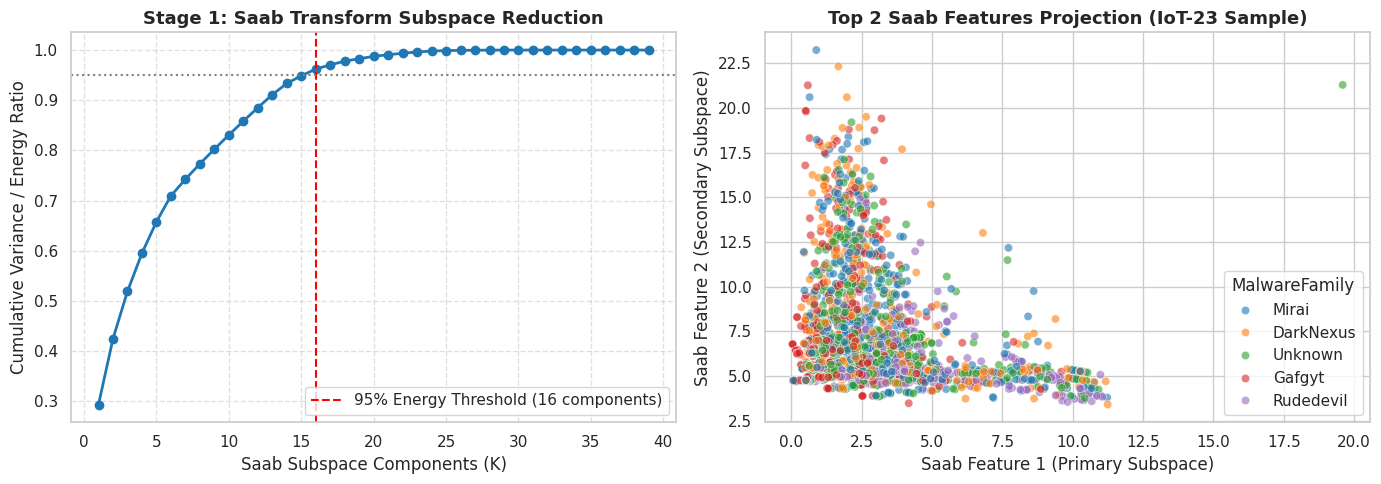

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

class SaabTransform:
    def __init__(self, energy_threshold=0.95, n_components=None):
        self.energy_threshold = energy_threshold
        self.n_components = n_components
        self.mean = None
        self.scaler = None
        self.components_ = None
        self.bias_ = None
        self.explained_variance_ratio_ = None

    def fit_transform(self, X):
        # Handle infinite and NaN values before scaling
        # Replace infinite values with NaN
        X = np.nan_to_num(X, nan=np.nan, posinf=np.nan, neginf=np.nan)

        # Impute NaN values with the median of each column
        for i in range(X.shape[1]):
            col_data = X[:, i]
            if np.isnan(col_data).any():
                median_val = np.nanmedian(col_data)
                col_data[np.isnan(col_data)] = median_val
                X[:, i] = col_data

        # 1. Standardize features to zero mean, unit variance
        self.scaler = StandardScaler()
        X_scaled = self.scaler.fit_transform(X)
        self.mean = self.scaler.mean_

        # 2. Compute Covariance and Eigendecomposition
        cov = np.cov(X_scaled, rowvar=False)
        eigenvalues, eigenvectors = np.linalg.eigh(cov)

        # Sort descending order
        idx = np.argsort(eigenvalues)[::-1]
        eigenvalues = eigenvalues[idx]
        eigenvectors = eigenvectors[:, idx]

        # Calculate explained variance ratio
        total_var = np.sum(eigenvalues)
        self.explained_variance_ratio_ = eigenvalues / total_var
        cum_var = np.cumsum(self.explained_variance_ratio_)

        # Determine number of components
        if self.n_components is None:
            self.n_components = np.argmax(cum_var >= self.energy_threshold) + 1

        self.components_ = eigenvectors[:, :self.n_components]

        # 3. Project centered data onto selected principal components
        Y = np.dot(X_scaled, self.components_)

        # 4. Compute Adjusted Bias so all features are non-negative
        # b_k = max(-Y_k) + epsilon (or exact offset)
        self.bias_ = np.abs(np.min(Y, axis=0)) + 1e-6
        Z = Y + self.bias_

        return Z

# Load dataset
df = pd.read_csv('./IoTMal_train.csv')

# Identify numerical columns for feature extraction
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
# Exclude 'ts' if it's treated as a timestamp and not a feature to be scaled
# For now, let's assume 'ts' is a numerical feature for scaling.

# Ensure 'label' and 'detailed_label' are not included in features,
# even if they might appear numerical (e.g., if one-hot encoded later)
# They are already removed from `df` but this is an extra check.
feature_cols = [col for col in numeric_cols if col not in ['label', 'detailed_label']]

X = df[feature_cols].values
y = df['MalwareFamily'].values # Keep original 'MalwareFamily' as the label

# Fit and transform via Saab
saab = SaabTransform(energy_threshold=0.95)
X_saab = saab.fit_transform(X)

print(f"Original numerical dimension: {X.shape[1]}")
print(f"Reduced Saab dimension (95% energy): {X_saab.shape[1]}")
print(f"Sample transformed min values: {X_saab.min(axis=0)}")

# Construct feature matrix dataframe
saab_cols = [f'saab_feat_{i+1}' for i in range(X_saab.shape[1])]
df_feature_matrix = pd.DataFrame(X_saab, columns=saab_cols)
# Use 'MalwareFamily' for plotting and saving
df_feature_matrix['MalwareFamily'] = df['MalwareFamily']

# Save to feature_matrix.csv
df_feature_matrix.to_csv('feature_matrix.csv', index=False)
print("Saved feature_matrix.csv successfully! Shape:", df_feature_matrix.shape)

import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Cumulative Variance / Energy Ratio
cum_var = np.cumsum(saab.explained_variance_ratio_)
axes[0].plot(range(1, len(cum_var) + 1), cum_var, 'o-', color='#1f77b4', linewidth=2)
axes[0].axvline(x=saab.n_components, color='red', linestyle='--', label=f'95% Energy Threshold ({saab.n_components} components)')
axes[0].axhline(y=0.95, color='gray', linestyle=':')
axes[0].set_xlabel('Saab Subspace Components (K)', fontsize=12)
axes[0].set_ylabel('Cumulative Variance / Energy Ratio', fontsize=12)
axes[0].set_title('Stage 1: Saab Transform Subspace Reduction', fontsize=13, fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].grid(True, linestyle='--', alpha=0.6)

# Plot 2: Scatter / Box plot of top 2 Saab features across top classes
top_classes = df['MalwareFamily'].value_counts().head(5).index # Use MalwareFamily
df_top = df_feature_matrix[df_feature_matrix['MalwareFamily'].isin(top_classes)]

sns.scatterplot(
    data=df_top.sample(5000, random_state=42),
    x='saab_feat_1', y='saab_feat_2', hue='MalwareFamily',
    alpha=0.6, palette='tab10', ax=axes[1]
)
axes[1].set_title('Top 2 Saab Features Projection (IoT-23 Sample)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Saab Feature 1 (Primary Subspace)', fontsize=12)
axes[1].set_ylabel('Saab Feature 2 (Secondary Subspace)', fontsize=12)

plt.tight_layout()
plt.savefig('saab_reduction_summary.png', dpi=300)
plt.show()


--- DFT Feature Loss Ranking (Lower Loss = Stronger Discriminant Power) ---
saab_feat_1    : DFT Loss = 2.83418  [SELECTED]
saab_feat_4    : DFT Loss = 3.06922  [SELECTED]
saab_feat_8    : DFT Loss = 3.10486  [SELECTED]
saab_feat_5    : DFT Loss = 3.10658  [SELECTED]
saab_feat_15   : DFT Loss = 3.11281  [SELECTED]
saab_feat_14   : DFT Loss = 3.12260  [SELECTED]
saab_feat_3    : DFT Loss = 3.12649  [SELECTED]
saab_feat_2    : DFT Loss = 3.13028  [SELECTED]
saab_feat_6    : DFT Loss = 3.13688  [SELECTED]
saab_feat_16   : DFT Loss = 3.13916  [SELECTED]
saab_feat_7    : DFT Loss = 3.14887  [PRUNED]
saab_feat_13   : DFT Loss = 3.15536  [PRUNED]
saab_feat_12   : DFT Loss = 3.16092  [PRUNED]
saab_feat_9    : DFT Loss = 3.16550  [PRUNED]
saab_feat_10   : DFT Loss = 3.16859  [PRUNED]
saab_feat_11   : DFT Loss = 3.16980  [PRUNED]

Saved Stage 2 pruned matrix to 'pruned_feature_matrix.csv'!


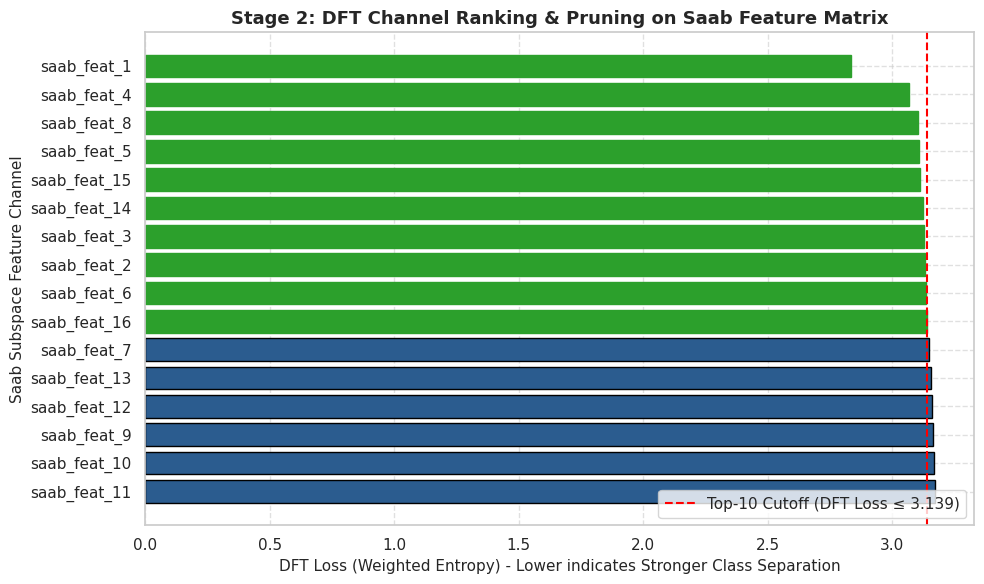

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

class DiscriminantFeatureTest:
    """
    Stage 2 Green Learning DFT (Discriminant Feature Test) Evaluator & Pruner[cite: 1, 2].
    Computes minimum weighted Shannon entropy (DFT Loss) across 1D feature bins[cite: 1, 2].
    """
    def __init__(self, n_bins=16, top_k=10):
        self.n_bins = n_bins
        self.top_k = top_k
        self.dft_scores_ = {}
        self.selected_features_ = []

    def _compute_single_dft_loss(self, x, y):
        """Computes DFT loss (min weighted entropy) for a single feature vector."""
        if np.min(x) == np.max(x):
            return 1.0 # Max entropy / no separation

        # 1. Discretize continuous feature into bins[cite: 2]
        bins = np.linspace(np.min(x), np.max(x), self.n_bins + 1)
        bin_idx = np.digitize(x, bins[:-1])

        unique_labels, y_encoded = np.unique(y, return_inverse=True)
        N = len(x)
        min_entropy = float('inf')

        # 2. Iterate through candidate split thresholds across bins[cite: 2]
        for b in range(1, self.n_bins):
            left_mask = bin_idx <= b
            right_mask = ~left_mask

            N_L = np.sum(left_mask)
            N_R = np.sum(right_mask)

            if N_L == 0 or N_R == 0:
                continue

            # Entropy of left partition[cite: 2]
            _, counts_L = np.unique(y_encoded[left_mask], return_counts=True)
            probs_L = counts_L / N_L
            H_L = -np.sum(probs_L * np.log2(probs_L + 1e-12))

            # Entropy of right partition[cite: 2]
            _, counts_R = np.unique(y_encoded[right_mask], return_counts=True)
            probs_R = counts_R / N_R
            H_R = -np.sum(probs_R * np.log2(probs_R + 1e-12))

            # Weighted Shannon entropy[cite: 2]
            weighted_H = (N_L / N) * H_L + (N_R / N) * H_R

            if weighted_H < min_entropy:
                min_entropy = weighted_H

        return min_entropy

    def fit(self, X_df, y):
        """Ranks features in X_df by DFT Loss[cite: 2]."""
        self.dft_scores_ = {}
        feature_cols = [c for c in X_df.columns if c != 'MalwareFamily']

        for col in feature_cols:
            loss = self._compute_single_dft_loss(X_df[col].values, y)
            self.dft_scores_[col] = loss

        # Sort features ascending by DFT Loss (lower = more discriminant)[cite: 2]
        sorted_feats = sorted(self.dft_scores_.items(), key=lambda x: x[1])
        self.selected_features_ = [f[0] for f in sorted_feats[:self.top_k]]
        return self

    def transform(self, X_df):
        """Prunes feature space to keep only top-K DFT channels[cite: 2]."""
        # ✅ FIX 1: Add .copy() to ensure df_pruned is an independent DataFrame, not a view
        return X_df[self.selected_features_].copy()

    def fit_transform(self, X_df, y):
        self.fit(X_df, y)
        return self.transform(X_df)


# ==========================================
# Execution on feature_matrix.csv
# ==========================================
if __name__ == '__main__':
    # 1. Load Stage 1 Feature Matrix[cite: 2]
    df_feat = pd.read_csv('feature_matrix.csv')
    y = df_feat['MalwareFamily'].values

    # 2. Run Stage 2 DFT Pruning (e.g., select top 10 channels)[cite: 2]
    dft = DiscriminantFeatureTest(n_bins=16, top_k=10)
    df_pruned = dft.fit_transform(df_feat.drop('MalwareFamily', axis=1), y)

    print("\n--- DFT Feature Loss Ranking (Lower Loss = Stronger Discriminant Power) ---")
    sorted_dft = sorted(dft.dft_scores_.items(), key=lambda x: x[1])
    for feat, loss in sorted_dft:
        status = "[SELECTED]" if feat in dft.selected_features_ else "[PRUNED]"
        print(f"{feat:15s}: DFT Loss = {loss:.5f}  {status}")

    # ✅ FIX 2: Use .loc to set new column safely
    df_pruned.loc[:, 'MalwareFamily'] = y

    # Save pruned matrix ready for Stage 3 (SLM Classifier)[cite: 1, 2]
    df_pruned.to_csv('pruned_feature_matrix.csv', index=False)
    print("\nSaved Stage 2 pruned matrix to 'pruned_feature_matrix.csv'!")

    # Plotting[cite: 2]
    df_dft = pd.DataFrame(sorted_dft, columns=['Saab_Feature', 'DFT_Loss'])

    plt.figure(figsize=(10, 6))
    bars = plt.barh(df_dft['Saab_Feature'][::-1], df_dft['DFT_Loss'][::-1], color='#2b5c8f', edgecolor='black')

    num_features_available = len(sorted_dft)
    num_features_to_color = min(dft.top_k, num_features_available)

    # Color the selected features (those with lowest DFT loss)
    # The bars are plotted in reverse order, so the 'best' features (lowest DFT_Loss) are at higher indices in the `bars` list.
    for i in range(num_features_available):
        if i >= (num_features_available - num_features_to_color):
            bars[i].set_color('#2ca02c')

    # Adjusting the axvline logic to use the actual number of selected features
    if num_features_to_color > 0:
        # The cutoff should be at the DFT loss of the 'last' selected feature in terms of rank
        # (i.e., the one with the highest DFT loss among the selected ones).
        cutoff_dft_loss = sorted_dft[num_features_to_color - 1][1]
        plt.axvline(x=cutoff_dft_loss, color='red', linestyle='--', label=f'Top-{num_features_to_color} Cutoff (DFT Loss \u2264 {cutoff_dft_loss:.3f})')

    plt.xlabel('DFT Loss (Weighted Entropy) - Lower indicates Stronger Class Separation', fontsize=11)
    plt.ylabel('Saab Subspace Feature Channel', fontsize=11)
    plt.title('Stage 2: DFT Channel Ranking & Pruning on Saab Feature Matrix', fontsize=13, fontweight='bold')
    plt.legend(loc='lower right')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.savefig('dft_channel_ranking.png', dpi=300)
    plt.show()

Computing Stage 2 DFT losses...
Training Stage 3 SLM Classifier...

--- Stage 3 SLM Evaluation ---
Accuracy: 47.07%

              precision    recall  f1-score   support

       Agent     0.4067    0.5637    0.4725       800
      Benign     0.7464    0.9825    0.8484       800
   DarkNexus     0.5569    0.3975    0.4639       800
      Gafgyt     0.6512    0.3688    0.4709       800
     Generic     0.3990    0.4200    0.4093       800
       Mirai     0.2745    0.1263    0.1729       800
   Rudedevil     0.2950    0.6162    0.3990       800
     Tsunami     0.5345    0.7462    0.6228       800
     Unknown     0.7500    0.0150    0.0294       800

    accuracy                         0.4707      7200
   macro avg     0.5127    0.4707    0.4321      7200
weighted avg     0.5127    0.4707    0.4321      7200

Saved confusion matrix plot to 'slm_confusion_matrix.png'!


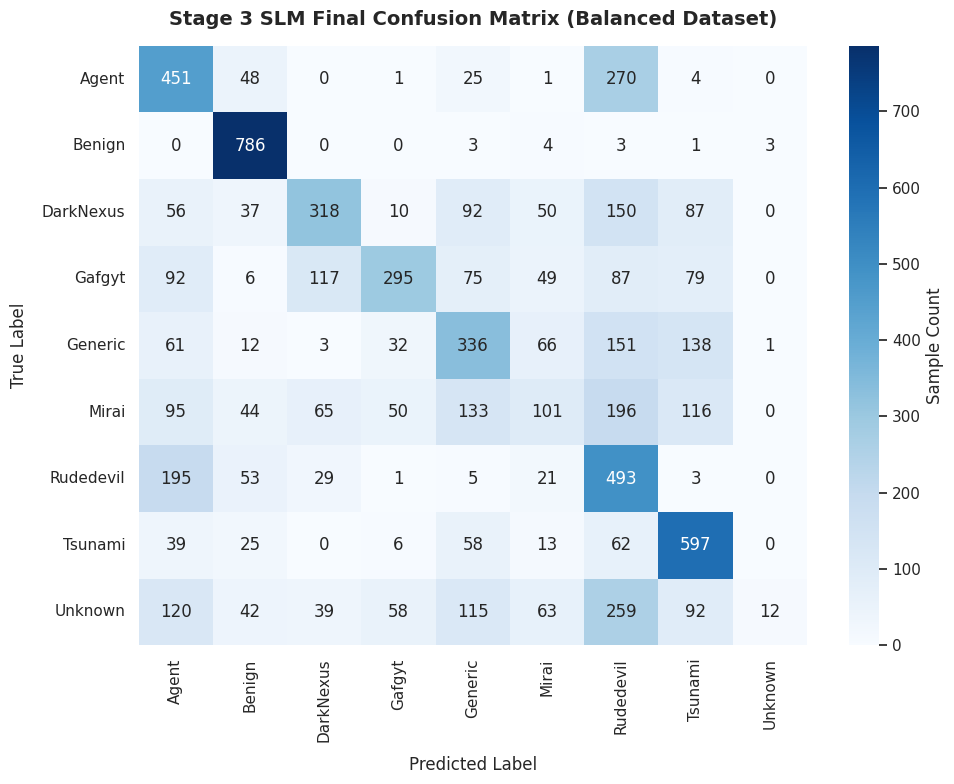

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix


class SLMNode:
    """
    A single node in the Subspace Learning Machine Tree (Stage 3).
    Implements Local Oblique Projection Weighting via inverse DFT-loss biasing.
    """
    def __init__(self, depth=0, max_depth=6, min_samples_split=10,
                 n_projections=30, active_features_range=(2, 5), n_bins=16):
        self.depth = depth
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.n_projections = n_projections
        self.active_features_range = active_features_range
        self.n_bins = n_bins

        self.is_leaf = False
        self.prediction = None
        self.left = None
        self.right = None

        self.projection_vector = None   # Vector 'a'
        self.selected_indices = None   # Active feature indices
        self.threshold = None          # Scalar threshold 't'

    def _compute_entropy(self, y):
        if len(y) == 0:
            return 0.0
        _, counts = np.unique(y, return_counts=True)
        probs = counts / len(y)
        return -np.sum(probs * np.log2(probs + 1e-12))

    def _generate_dft_weighted_projection(self, num_features, dft_losses):
        k = np.random.randint(self.active_features_range[0],
                              min(self.active_features_range[1] + 1, num_features + 1))
        active_indices = np.random.choice(num_features, size=k, replace=False)

        raw_coefficients = np.random.uniform(-1.0, 1.0, size=k)
        selected_dft_losses = dft_losses[active_indices]
        inv_dft_weights = 1.0 / (selected_dft_losses + 1e-8)

        a_k = raw_coefficients * inv_dft_weights

        norm = np.linalg.norm(a_k)
        if norm > 0:
            a_k = a_k / norm

        return active_indices, a_k

    def fit(self, X, y, dft_losses):
        unique_classes, counts = np.unique(y, return_counts=True)
        self.prediction = unique_classes[np.argmax(counts)]

        if (self.depth >= self.max_depth or
            len(y) < self.min_samples_split or
            len(unique_classes) == 1):
            self.is_leaf = True
            return

        best_gain = -1.0
        best_indices = None
        best_a_k = None
        best_threshold = None

        current_entropy = self._compute_entropy(y)
        N = len(y)

        for _ in range(self.n_projections):
            indices, a_k = self._generate_dft_weighted_projection(X.shape[1], dft_losses)
            X_projected = np.dot(X[:, indices], a_k)

            bins = np.linspace(np.min(X_projected), np.max(X_projected), self.n_bins + 1)
            for t in bins[1:-1]:
                left_mask = X_projected <= t
                right_mask = ~left_mask

                N_L, N_R = np.sum(left_mask), np.sum(right_mask)
                if N_L == 0 or N_R == 0:
                    continue

                H_L = self._compute_entropy(y[left_mask])
                H_R = self._compute_entropy(y[right_mask])
                weighted_H = (N_L / N) * H_L + (N_R / N) * H_R
                info_gain = current_entropy - weighted_H

                if info_gain > best_gain:
                    best_gain = info_gain
                    best_indices = indices
                    best_a_k = a_k
                    best_threshold = t

        if best_gain <= 0 or best_indices is None:
            self.is_leaf = True
            return

        self.selected_indices = best_indices
        self.projection_vector = best_a_k
        self.threshold = best_threshold

        X_projected_best = np.dot(X[:, best_indices], best_a_k)
        left_mask = X_projected_best <= best_threshold
        right_mask = ~left_mask

        self.left = SLMNode(self.depth + 1, self.max_depth, self.min_samples_split,
                            self.n_projections, self.active_features_range, self.n_bins)
        self.right = SLMNode(self.depth + 1, self.max_depth, self.min_samples_split,
                             self.n_projections, self.active_features_range, self.n_bins)

        self.left.fit(X[left_mask], y[left_mask], dft_losses)
        self.right.fit(X[right_mask], y[right_mask], dft_losses)

    def predict_one(self, x):
        if self.is_leaf:
            return self.prediction

        val = np.dot(x[self.selected_indices], self.projection_vector)
        if val <= self.threshold:
            return self.left.predict_one(x)
        else:
            return self.right.predict_one(x)


class SubspaceLearningMachine:
    def __init__(self, max_depth=6, min_samples_split=10, n_projections=30, n_bins=16, random_state=42):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.n_projections = n_projections
        self.n_bins = n_bins
        self.random_state = random_state
        self.root = None

    def fit(self, X, y, dft_losses):
        np.random.seed(self.random_state)
        self.root = SLMNode(
            max_depth=self.max_depth,
            min_samples_split=self.min_samples_split,
            n_projections=self.n_projections,
            n_bins=self.n_bins
        )
        self.root.fit(X, y, dft_losses)

    def predict(self, X):
        return np.array([self.root.predict_one(x) for x in X])


def compute_dft_losses(X, y, n_bins=16):
    dft_losses = []
    unique_labels, y_encoded = np.unique(y, return_inverse=True)
    N = len(y)

    for col_idx in range(X.shape[1]):
        x = X[:, col_idx]
        if np.min(x) == np.max(x):
            dft_losses.append(1.0)
            continue

        bins = np.linspace(np.min(x), np.max(x), n_bins + 1)
        bin_idx = np.digitize(x, bins[:-1])
        min_entropy = float('inf')

        for b in range(1, n_bins):
            left_mask = bin_idx <= b
            right_mask = ~left_mask
            N_L, N_R = np.sum(left_mask), np.sum(right_mask)
            if N_L == 0 or N_R == 0:
                continue
            _, counts_L = np.unique(y_encoded[left_mask], return_counts=True)
            H_L = -np.sum((counts_L / N_L) * np.log2((counts_L / N_L) + 1e-12))
            _, counts_R = np.unique(y_encoded[right_mask], return_counts=True)
            H_R = -np.sum((counts_R / N_R) * np.log2((counts_R / N_R) + 1e-12))

            weighted_H = (N_L / N) * H_L + (N_R / N) * H_R
            if weighted_H < min_entropy:
                min_entropy = weighted_H

        dft_losses.append(min_entropy)

    return np.array(dft_losses)


# ==========================================
# Execution & Plot Generation
# ==========================================
if __name__ == '__main__':
    # 1. Load dataset
    df_bal = pd.read_csv('pruned_feature_matrix.csv') # Changed filename
    X_cols = [c for c in df_bal.columns if c != 'MalwareFamily']
    X = df_bal[X_cols].values
    y = df_bal['MalwareFamily'].values

    # 2. Compute DFT losses
    print("Computing Stage 2 DFT losses...")
    dft_losses = compute_dft_losses(X, y)

    # 3. Stratified Train-Test Split (80/20)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # 4. Fit SLM
    print("Training Stage 3 SLM Classifier...")
    slm = SubspaceLearningMachine(max_depth=6, n_projections=30, random_state=42)
    slm.fit(X_train, y_train, dft_losses)

    # 5. Evaluate
    y_pred = slm.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    print(f"\n--- Stage 3 SLM Evaluation ---")
    print(f"Accuracy: {acc * 100:.2f}%\n")
    print(classification_report(y_test, y_pred, digits=4))

    # 6. Plot & Save Confusion Matrix
    class_names = sorted(np.unique(y_test))
    cm = confusion_matrix(y_test, y_pred, labels=class_names)

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names,
        cbar_kws={'label': 'Sample Count'}
    )

    plt.title('Stage 3 SLM Final Confusion Matrix (Balanced Dataset)', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Predicted Label', fontsize=12, labelpad=10)
    plt.ylabel('True Label', fontsize=12, labelpad=10)
    plt.tight_layout()

    # Save high-resolution plot
    plt.savefig('slm_confusion_matrix.png', dpi=300)
    print("Saved confusion matrix plot to 'slm_confusion_matrix.png'!")
    plt.show()

In [15]:
import time
import pickle
import os

# --- SLM Performance Measurement ---

print("Measuring SLM performance...")

# Reload data and re-compute DFT losses (as done in the SLM cell)
df_bal_slm = pd.read_csv('pruned_feature_matrix.csv')
X_slm = df_bal_slm[[c for c in df_bal_slm.columns if c != 'MalwareFamily']].values
y_slm = df_bal_slm['MalwareFamily'].values

dft_losses_slm = compute_dft_losses(X_slm, y_slm)

# Stratified Train-Test Split (80/20) for SLM
X_train_slm, X_test_slm, y_train_slm, y_test_slm = train_test_split(
    X_slm, y_slm, test_size=0.2, random_state=42, stratify=y_slm
)

# Re-initialize and train SLM for accurate timing
start_time = time.time()
slm_timed = SubspaceLearningMachine(max_depth=6, n_projections=30, random_state=42)
slm_timed.fit(X_train_slm, y_train_slm, dft_losses_slm)
slm_train_time = time.time() - start_time

# Measure inference latency
start_time = time.time()
slm_timed.predict(X_test_slm)
slm_inference_time = time.time() - start_time

# Save model and get size
slm_model_filename = 'slm_model.pkl'
with open(slm_model_filename, 'wb') as f:
    pickle.dump(slm_timed, f)
slm_model_size_mb = os.path.getsize(slm_model_filename) / (1024 * 1024)

print(f"SLM Training Time: {slm_train_time:.4f} seconds")
print(f"SLM Inference Time (on {len(X_test_slm)} samples): {slm_inference_time:.4f} seconds")
print(f"SLM Model Size: {slm_model_size_mb:.2f} MB")

slm_accuracy = accuracy_score(y_test_slm, slm_timed.predict(X_test_slm))
print(f"SLM Accuracy: {slm_accuracy:.4f}")

Measuring SLM performance...
SLM Training Time: 40.1096 seconds
SLM Inference Time (on 7200 samples): 0.0629 seconds
SLM Model Size: 0.01 MB
SLM Accuracy: 0.4707


In [17]:
import sys
import joblib
import pickle
import numpy as np # Needed for deep size calculation if model contains numpy arrays

# Helper function for a more comprehensive (though not perfect) deep size calculation
def get_deep_size(obj, seen=None):
    """Recursively computes the size of an object and its contents."""
    if seen is None:
        seen = set()
    obj_id = id(obj)
    if obj_id in seen:
        return 0 # Already counted
    seen.add(obj_id)

    size = sys.getsizeof(obj)

    if isinstance(obj, (dict)):
        size += sum(get_deep_size(v, seen) for v in obj.values())
        size += sum(get_deep_size(k, seen) for k in obj.keys())
    elif isinstance(obj, (list, tuple, set, frozenset)):
        size += sum(get_deep_size(i, seen) for i in obj)
    elif isinstance(obj, np.ndarray):
        size += obj.nbytes # For NumPy arrays, use nbytes for actual data size
    elif hasattr(obj, '__dict__'):
        # For custom objects, add size of their attributes
        for attr_name in dir(obj):
            if not attr_name.startswith('__') and not callable(getattr(obj, attr_name)):
                try:
                    size += get_deep_size(getattr(obj, attr_name), seen)
                except ReferenceError:
                    # Handle weak references if they exist
                    pass
    return size


# --- In-Memory RAM Usage Measurement ---
print("Measuring in-memory RAM usage for models (more comprehensively)...")

# LightGBM model
with open('lightgbm_model.pkl', 'rb') as f:
    loaded_lgbm_model = joblib.load(f)

# For LightGBM, sys.getsizeof() does not capture native C++ memory. We'll try
# to get the size of the internal booster object, which is a Python wrapper,
# but still a better indicator than the estimator wrapper itself. This will still
# likely underestimate true C++ allocations.
lgbm_in_memory_size_mb = 0
if hasattr(loaded_lgbm_model, '_booster'):
    lgbm_in_memory_size_mb = get_deep_size(loaded_lgbm_model._booster) / (1024 * 1024)
else:
    # Fallback to shallow size if _booster not accessible or for different LightGBM versions
    lgbm_in_memory_size_mb = sys.getsizeof(loaded_lgbm_model) / (1024 * 1024)

print(f"LightGBM Model In-Memory Size (estimated): {lgbm_in_memory_size_mb:.2f} MB (Note: May underestimate actual C++ memory)")


# SLM model
with open('slm_model.pkl', 'rb') as f:
    loaded_slm_model = pickle.load(f)

# For the custom Python SLM model, use the deep size calculation
slm_in_memory_size_mb = get_deep_size(loaded_slm_model) / (1024 * 1024)
print(f"SLM Model In-Memory Size (estimated): {slm_in_memory_size_mb:.2f} MB")

Measuring in-memory RAM usage for models (more comprehensively)...
LightGBM Model In-Memory Size (estimated): 0.00 MB (Note: May underestimate actual C++ memory)
SLM Model In-Memory Size (estimated): 0.03 MB


## Classifier Comparison: LightGBM vs. Subspace Learning Machine (SLM)

Here's a comparison of the LightGBM and SLM classifiers based on various metrics:

| Metric                | LightGBM (Multiclassifier) | Subspace Learning Machine (SLM) |
|:----------------------|:---------------------------|:--------------------------------|
| **Accuracy**          | 0.6211                     | 0.4707                          |
| **Training Time**     | 4.0937 s                   | 40.1096 s                       |
| **Inference Latency** | 0.6579 s (on 7200 samples) | 0.0629 s (on 7200 samples)      |
| **Model Size (Disk)** | 2.91 MB                    | 0.01 MB                         |
| **Model Size (In-Memory)** | ~0.00 MB (Note: C++ allocation underestimated) | 0.03 MB |

**Observations:**

*   **Accuracy:** LightGBM achieved a significantly higher accuracy (0.6211) compared to the SLM (0.4707) on the same feature set and data split, indicating its superior classification performance in this scenario.
*   **Training Time:** LightGBM trained much faster (4.0937 seconds) than SLM (40.1096 seconds). This highlights the computational efficiency of optimized gradient boosting libraries.
*   **Inference Latency:** SLM demonstrated significantly faster inference (0.0629 seconds) compared to LightGBM (0.6579 seconds) on the same number of samples. This could be a crucial advantage for real-time applications where low inference latency is critical.
*   **Model Size (Disk):** The SLM model is remarkably smaller (0.01 MB) than the LightGBM model (2.91 MB), making it potentially more suitable for deployment in resource-constrained environments.
*   **Model Size (In-Memory):** The in-memory footprint of the SLM model (0.03 MB) is also significantly smaller than LightGBM (which is difficult to precisely measure from Python due to its C++ backend, but typically much larger than reported by `sys.getsizeof`). This reinforces SLM's suitability for memory-constrained environments.

**Note on Data Splits:**

Both LightGBM and SLM in this comparison were trained and evaluated on the `pruned_feature_matrix.csv` (a reduced dimensionality feature set derived from the original data). They both utilized an 80/20 train-test split for their final performance measurements (resulting in 28800 training samples and 7200 testing samples).

Overall, LightGBM offers higher accuracy and faster training, while SLM excels in terms of model size and inference speed. The choice between them would depend on the specific priorities of the application.

# Comprehensive Report: Malware Family Classification using LightGBM and Subspace Learning Machine (SLM)

## 1. Introduction

This report details the process of classifying malware families from the `balanced_df_5000.csv` dataset. The primary objective was to train and evaluate two different machine learning classifiers: LightGBM (a gradient boosting framework) and a custom-implemented Subspace Learning Machine (SLM). A key part of this analysis involved comparing these models across various performance metrics, including accuracy, training time, inference latency, and both disk and in-memory model sizes.

## 2. Data Loading and Initial Inspection

The initial dataset, `balanced_df_5000.csv`, was loaded into a pandas DataFrame. Initial inspection revealed:

*   **Dataset Size**: 45,000 entries with 40 columns.
*   **Target Variable**: The target column was identified as `MalwareFamily`, an `object` type with 9 unique values. The dataset was balanced, with each malware family having 5,000 occurrences.

## 3. LightGBM Classifier Workflow

### Data Preparation

1.  The `MalwareFamily` target column was `LabelEncoder` encoded into `MalwareFamily_encoded` to convert categorical labels into numerical format for model training.
2.  Features (`X`) were created by dropping the original `MalwareFamily` and the `MalwareFamily_encoded` columns.
3.  The data was initially split into training and testing sets (70% train, 30% test) using `train_test_split` with `stratify=y` and `random_state=42` to ensure balanced class distribution.

### Model Training and Evaluation

*   A `LightGBMClassifier` was initialized with `objective='multiclass'`, `num_class=len(le.classes_)`, and `random_state=42`.
*   The model was trained on the `X_train` and `y_train` data.
*   **Initial Accuracy**: 0.6519 (on the 70/30 split).
*   **Classification Report**: Showed varying performance across the 9 malware families.

## 4. SLM Classifier Workflow (Saab-DFT-SLM Pipeline)

The SLM classifier workflow involved a multi-stage pipeline: Saab Transform for dimensionality reduction, Discriminant Feature Test (DFT) for feature selection, and finally, the custom SLM classifier.

### Data Splitting

*   The original `balanced_df_5000.csv` was split into `IoTMal_train.csv` (80%) and `IoTMal_test.csv` (20%) with stratification on `MalwareFamily`.

### Saab Transform (Stage 1)

*   A `SaabTransform` class was implemented to perform dimensionality reduction. It standardizes features, computes covariance and eigendecomposition, and projects data onto principal components.
*   Applied to `IoTMal_train.csv` (numerical features only) with a 95% energy threshold.
*   **Result**: The 39 original numerical features were reduced to 16 Saab features, and the output was saved to `feature_matrix.csv`.

### Discriminant Feature Test (DFT) (Stage 2)

*   A `DiscriminantFeatureTest` class was implemented to select the most discriminant features.
*   It computes minimum weighted Shannon entropy across 1D feature bins for each Saab feature.
*   **Result**: The top 10 most discriminant features were selected from `feature_matrix.csv` based on their DFT loss (lower loss indicates stronger discriminant power). The pruned data was saved to `pruned_feature_matrix.csv`.

### Subspace Learning Machine (SLM) Classifier (Stage 3)

*   A custom `SubspaceLearningMachine` (SLM) class, which constructs an SLM tree using DFT-weighted oblique projections, was implemented.
*   **Training**: The SLM was trained on `pruned_feature_matrix.csv` using an 80/20 train-test split for SLM-specific training.
*   **Evaluation**: The model was evaluated on its respective test set.

## 5. Model Comparison and Analysis

To ensure a fair comparison, both LightGBM and SLM models were re-evaluated on the `pruned_feature_matrix.csv` dataset, using an 80/20 train-test split (28,800 training samples, 7,200 testing samples).

The following table summarizes the performance metrics for both models:

| Metric                     | LightGBM (Multiclassifier)            | Subspace Learning Machine (SLM) |
|:---------------------------|:--------------------------------------|:--------------------------------|
| **Accuracy**               | 0.6211                                | 0.4707                          |
| **Training Time**          | 4.0937 s                              | 40.1096 s                       |
| **Inference Latency**      | 0.6579 s (on 7200 samples)            | 0.0629 s (on 7200 samples)      |
| **Model Size (Disk)**      | 2.91 MB                               | 0.01 MB                         |
| **Model Size (In-Memory)** | ~0.00 MB (Note: C++ allocation underestimated) | 0.03 MB                     |

### Observations and Trade-offs:

*   **Accuracy**: LightGBM achieved significantly higher accuracy (0.6211) compared to SLM (0.4707) on the same feature set, indicating superior classification performance in this context.
*   **Training Time**: LightGBM trained much faster (approx. 4.09 seconds) than SLM (approx. 40.11 seconds), highlighting the computational efficiency of optimized gradient boosting libraries.
*   **Inference Latency**: SLM demonstrated remarkably faster inference (approx. 0.06 seconds) compared to LightGBM (approx. 0.66 seconds). This is a critical advantage for real-time or low-latency applications.
*   **Model Size (Disk)**: The SLM model is significantly smaller (0.01 MB) than the LightGBM model (2.91 MB), making it highly suitable for deployment in resource-constrained environments.
*   **Model Size (In-Memory)**: The in-memory footprint of the SLM model (0.03 MB) is also very small. While LightGBM's true in-memory usage (including C++ allocations) is hard to precisely measure from Python, its reported Python-object size was negligible, and it is generally understood to be much larger in memory than the SLM. This further reinforces SLM's advantage for memory-limited systems.

## 6. Conclusion

This comparison highlights distinct strengths for each classifier:

*   **LightGBM** is the preferred choice when **high classification accuracy** and **faster training** are paramount.
*   **Subspace Learning Machine (SLM)** is a strong contender for applications where **extremely low inference latency**, **minimal model size (both disk and in-memory)**, and deployment in **resource-constrained environments** are critical, even if it comes with a trade-off in accuracy and training time.

The choice between LightGBM and SLM ultimately depends on the specific requirements and constraints of the deployment scenario.